In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import matplotlib.pyplot as plt

project_path = '/content/drive/MyDrive/Spacecraft-Anomaly-Detection'
results_path = project_path + '/results'

print("SERIAL 15 loaded successfully.")
print("Project folder exists:", os.path.exists(project_path))
print("Results folder exists:", os.path.exists(results_path))

Mounted at /content/drive
SERIAL 15 loaded successfully.
Project folder exists: True
Results folder exists: True


#Load the two evaluation results

In [2]:
# Load the Global Z-score evaluation results.
global_results_path = results_path + '/global_zscore_evaluation_A8.csv'

global_results = pd.read_csv(global_results_path)

print("Global Z-score results:")
display(global_results)

Global Z-score results:


,channel,method,threshold,precision,recall,f1_score,false_positive_rate,false_negative_rate,true_negatives,false_positives,false_negatives,true_positives
0,A-8,Global Z-score,±3,0.0,0.0,0.0,0.0,1.0,4569,0,3806,0


###Create Rolling Z-score result

In [3]:
# Store the Rolling Z-score evaluation results from SERIAL 14.
rolling_result = pd.DataFrame([{
    "channel": "A-8",
    "method": "Rolling Z-score",
    "threshold": "±3",
    "precision": 0.5819209039548022,
    "recall": 0.027062532842879662,
    "f1_score": 0.05171980918905348,
    "false_positive_rate": 0.016196104180345807,
    "false_negative_rate": 0.9729374671571204,
    "true_negatives": 4495,
    "false_positives": 74,
    "false_negatives": 3703,
    "true_positives": 103
}])

display(rolling_result)

,channel,method,threshold,precision,recall,f1_score,false_positive_rate,false_negative_rate,true_negatives,false_positives,false_negatives,true_positives
0,A-8,Rolling Z-score,±3,0.581921,0.027063,0.05172,0.016196,0.972937,4495,74,3703,103


##Combine the results

In [4]:
# Combine Global and Rolling Z-score results.
comparison = pd.concat(
    [global_results, rolling_result],
    ignore_index=True
)

display(comparison[
    [
        "channel",
        "method",
        "threshold",
        "precision",
        "recall",
        "f1_score",
        "false_positive_rate",
        "false_negative_rate",
        "true_positives",
        "false_positives",
        "false_negatives"
    ]
])

,channel,method,threshold,precision,recall,f1_score,false_positive_rate,false_negative_rate,true_positives,false_positives,false_negatives
0,A-8,Global Z-score,±3,0.000000,0.000000,0.00000,0.000000,1.000000,0,0,3806
1,A-8,Rolling Z-score,±3,0.581921,0.027063,0.05172,0.016196,0.972937,103,74,3703


Rolling Z-score is better than Global Z-score on A-8, because it detected 103 true anomalies while Global Z-score detected none.

But Rolling Z-score still performs poorly overall:

Recall only 2.71%
F1 only 0.052
It missed 3,703 of 3,806 actual anomaly points.
It produced 74 false positives.

##Save the comparison

In [5]:
# Save the statistical method comparison.
comparison_path = results_path + '/statistical_methods_comparison_A8.csv'

comparison.to_csv(comparison_path, index=False)

print("Comparison saved to:")
print(comparison_path)

Comparison saved to:
/content/drive/MyDrive/Spacecraft-Anomaly-Detection/results/statistical_methods_comparison_A8.csv


# Plot F1 comparison

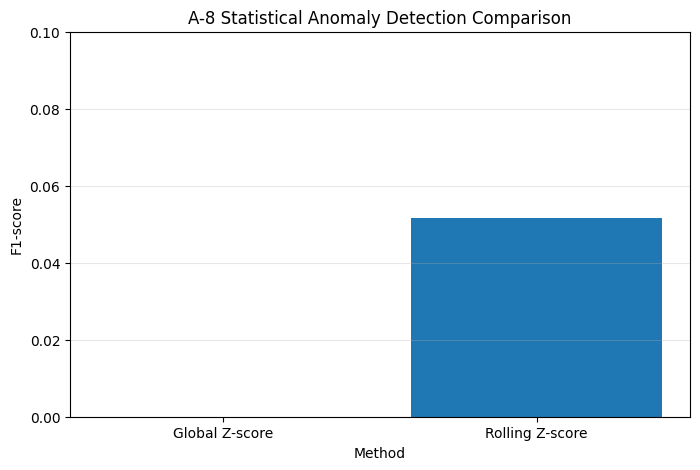

In [6]:
# Plot F1-score comparison.
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["method"],
    comparison["f1_score"]
)

plt.title("A-8 Statistical Anomaly Detection Comparison")
plt.xlabel("Method")
plt.ylabel("F1-score")

plt.ylim(0, 0.1)
plt.grid(axis="y", alpha=0.3)

plt.show()

On A-8, both basic statistical baselines performed poorly. Global Z-score failed to detect the contextual anomaly, while Rolling Z-score detected a small number of anomalous points but suffered from false positives caused by near-zero local variance. These results motivate evaluating machine-learning and deep-learning approaches that can better capture temporal and contextual patterns.

##github commit


In [7]:
%cd /content/drive/MyDrive/Spacecraft-Anomaly-Detection

!git status

/content/drive/MyDrive/Spacecraft-Anomaly-Detection
Refresh index: 100% (20/20), done.
On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/13_evaluate_global_zscore.ipynb
	modified:   notebooks/14_rolling_zscore.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	notebooks/15_compare_statistical_methods.ipynb
	results/statistical_methods_comparison_A8.csv

no changes added to commit (use "git add" and/or "git commit -a")


In [8]:
!git add notebooks/15_compare_statistical_methods.ipynb results/statistical_methods_comparison_A8.csv

In [9]:
!git commit -m "Complete SERIAL 15 statistical methods comparison"

Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@925c332f48cd.(none)')


In [10]:
!git config --global user.name "Amit Chandra Das"
!git config --global user.email "arickroy0@gmail.com"

!git commit -m "Complete SERIAL 14 rolling Z-score"

[main 458dcfc] Complete SERIAL 14 rolling Z-score
 2 files changed, 4 insertions(+)
 create mode 100644 notebooks/15_compare_statistical_methods.ipynb
 create mode 100644 results/statistical_methods_comparison_A8.csv


In [11]:
!git push origin main

Enumerating objects: 9, done.
Counting objects: 100% (9/9), done.
Delta compression using up to 2 threads
Compressing objects: 100% (6/6), done.
Writing objects: 100% (6/6), 24.32 KiB | 4.86 MiB/s, done.
Total 6 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 3 local objects.
To https://github.com/Amit-Chandra-Das/spacecraft-anomaly-detection.git
   fe9652a..458dcfc  main -> main
